In [62]:
class Node():
    def __init__(self, value, left=None, right=None):
        self.value = value
        self.left = left
        self.right = right

### 100. Same Tree

#### Given the roots of two binary trees p and q, write a function to check if they are the same or not.

#### Two binary trees are considered the same if they are structurally identical, and the nodes have the same value.

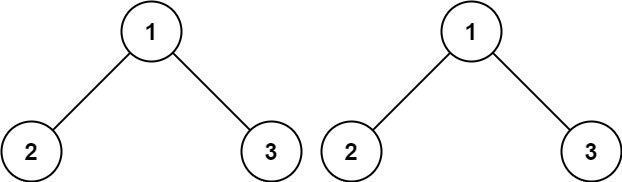

In [63]:
# left subtree
t1 = Node(1)
t1.left = Node(2)
t1.right = Node(3)

# right subtree
t2 = Node(1)
t2.left = Node(2)
t2.right = Node(3)

In [64]:
def sameTree(t1, t2):
    if t1 is None and t2 is None:
        return True
    if t1 is None or t2 is None:
        return False
    if t1.value != t2.value:
        return False
    
    left = sameTree(t1.left, t2.left)
    right = sameTree(t1.right, t2.right)
    return left and right

sameTree(t1, t2)

True

### 872. Leaf-Similar Trees

#### Consider all the leaves of a binary tree, from left to right order, the values of those leaves form a leaf value sequence.

In [65]:
root = Node(3)
five = Node(5)
one = Node(1)
six = Node(6)
two = Node(2)
nine = Node(9)
eight = Node(8)
seven = Node(7)
four = Node(4)

# left subtree
root.left = five
five.left = six
five.right = two
two.left = seven
two.right = four

# right subtree
root.right = one
one.left = nine
one.right = eight

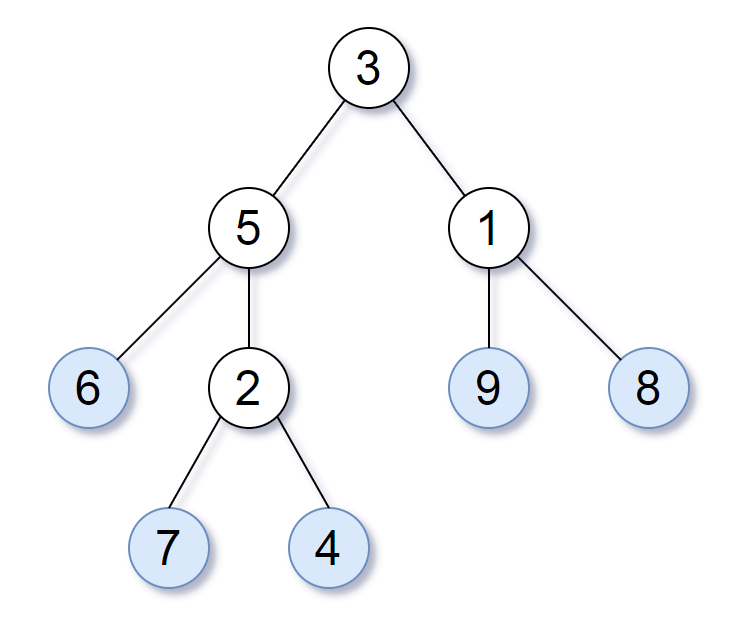

In [66]:
def leafSimilar(root):
    if root is None:
        return None
    
    def dfs(node, leafs=[]):
        if node is None:
            return
        
        if node.left is None and node.right is None:
            leafs.append(node.value)
            
        dfs(node.left)
        dfs(node.right)
        return leafs
    
    return dfs(root)

In [67]:
leafSimilar(root)

[6, 7, 4, 9, 8]

### 226. Invert Binary Tree
#### Given the root of a binary tree, invert the tree, and return its root.

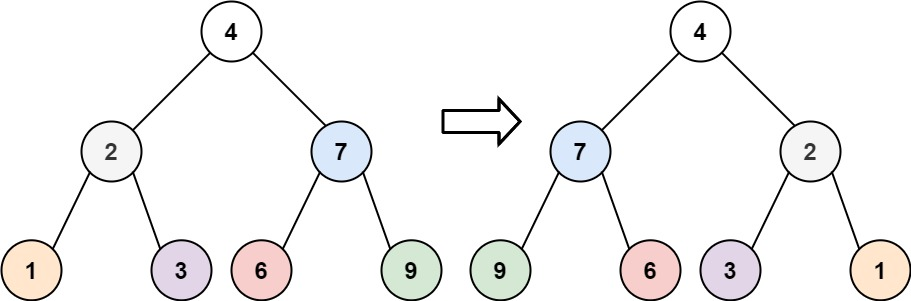

In [68]:
root = Node(4)
two = Node(2)
seven = Node(7)
one = Node(1)
three = Node(3)
six = Node(6)
nine = Node(9)

# left subtree
root.left = two
two.left = one
two.right = three

# right subtree
root.right = seven
seven.left = six
seven.right = nine

In [69]:
from collections import deque

def invertBT(root):
    levels = []
    if root is None:
        return None
    
    queue = deque([root])
    while queue:
        level = []
        for _ in range(len(queue)):
            node = queue.popleft()
            level.append(node.value)
            
            if node.left:
                queue.append(node.left)
            if node.right:
                queue.append(node.right)
        levels.append(level)
    return levels
            
invertBT(root)      

[[4], [2, 7], [1, 3, 6, 9]]

### 101. Symmetric Tree

#### Given the root of a binary tree, check whether it is a mirror of itself (i.e., symmetric around its center).


In [70]:
root = Node(1)

# left subtree
root.left = Node(2)
root.left.left = Node(3)
root.left.right = Node(4)

# right subtree
root.right = Node(2)
root.right.left = Node(4)
root.right.right = Node(3)

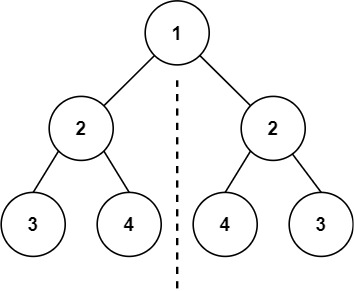

In [71]:
def symmetricTree(root):
    if root is None:
        return None
    
    stack = [root, root]
    while stack:
        L, R = stack.pop(), stack.pop()
        
        if L is None and R is None:
            continue
        if L is None or R is None:
            return False
        if L.value != R.value:
            return False
        
        stack.append(L.left)
        stack.append(R.right)
        stack.append(L.right)
        stack.append(R.left)
    return True

symmetricTree(root)

True

In [72]:
def symmetricTree(root):
    if root is None:
        return None
    
    def dfs(t1, t2):
        if t1 is None and t2 is None:
            return True
        if t1 is None or t2 is None:
            return False
        if t1.value != t2.value:
            return False
        
        dfs(t1.left, t2.right)
        dfs(t1.right, t2.left)
        
    dfs(root, root)
    return True

symmetricTree(root)

True

### 113. Path Sum II
#### Given the root of a binary tree and an integer targetSum, return all root-to-leaf paths where the sum of the node values in the path equals targetSum. Each path should be returned as a list of the node values, not node references.

#### A root-to-leaf path is a path starting from the root and ending at any leaf node. A leaf is a node with no children.

In [94]:
root = Node(5)
four = Node(4)
eight = Node(8)
eleven = Node(11)
thirteen = Node(13)
four_ = Node(4)
seven = Node(7)
two = Node(2)
five_ = Node(5)
one = Node(1)

# left subtree
root.left = four
four.left = eleven
eleven.left = seven
eleven.right = two

# right subtree
root.right = eight
eight.left = thirteen
eight.right = four_
four_.left = five_
four_.right = one

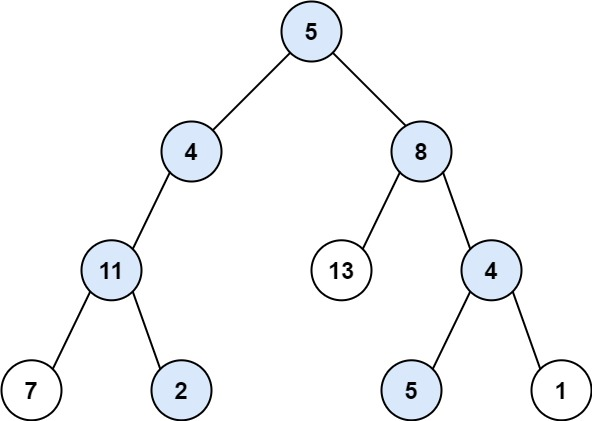

In [96]:
def pathSum(root, target):
    paths = []
    if root is None:
        return None
    
    stack = [(root, root.value, [root.value])]
    while stack:
        node, curr_sum, curr_path = stack.pop()
        
        if curr_sum == target:
            paths.append(curr_path)
        
        if node.right:
            stack.append((node.right,
                         curr_sum + node.right.value,
                         curr_path + [node.right.value]))
        if node.left:
            stack.append((node.left,
                          curr_sum + node.left.value,
                          curr_path + [node.left.value]))
    return paths
            
pathSum(root, 22)

[[5, 4, 11, 2], [5, 8, 4, 5]]

### 1325. Delete Leaves With a Given Value
#### Given a binary tree root and an integer target, delete all the leaf nodes with value target.

#### Note that once you delete a leaf node with value target, if its parent node becomes a leaf node and has the value target, it should also be deleted (you need to continue doing that until you cannot).

In [97]:
root = Node(1)

# left subtree
root.left = Node(2)
root.left.left = Node(2)

# right subtree
root.right = Node(3)
root.right.left = Node(2)
root.right.right = Node(4)

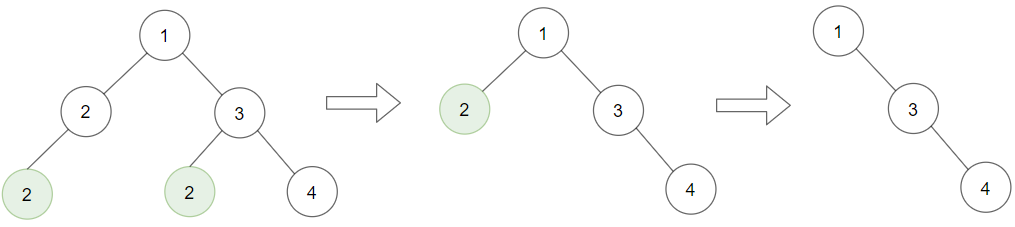

In [98]:
def deleteLeaves(root, target):
    if root is None:
        return []
    
    stack = [(root, None)]
    while stack:
        node, parent = stack.pop()
        
        if node.left is None and node.right is None:
            if node is parent.left:
                parent.left = None
            else:
                parent.right = None
        
        if node.right:
            stack.append((node.right, node))
        if node.left:
            stack.append((node.left, node))
    return root

deleteLeaves(root, 2)

### 437. Path Sum III
#### Given the root of a binary tree and an integer targetSum, return the number of paths where the sum of the values along the path equals targetSum.

#### The path does not need to start or end at the root or a leaf, but it must go downwards (i.e., traveling only from parent nodes to child nodes).

In [100]:
root = Node(10)

# left subtree
five = Node(5)
root.left = five
three = Node(3)
two = Node(2)
five.left = three
five.right = two
three.left = Node(3)
three.right = Node(-2)
two.right = Node(1)


# right subtree
root.right = Node(-3)
eleven = Node(11)
root.right.right = eleven

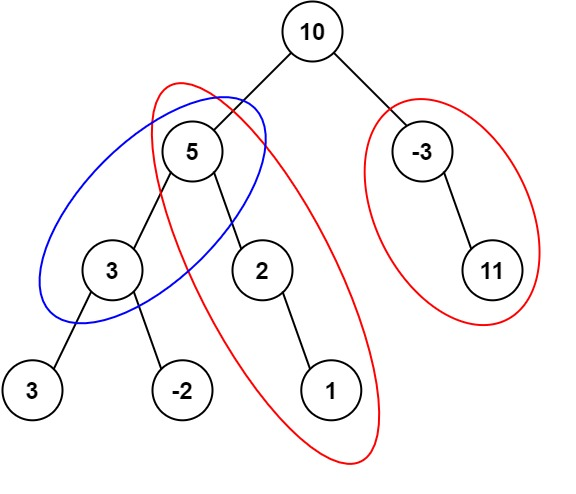

In [103]:
def pathSum(root, target):
    paths = []
    if root is None:
        return None
    
    stack = [(root, 0, [])]
    while stack:
        node, curr_sum, curr_path = stack.pop()
        
        if curr_path and curr_sum == target:
            paths.append(curr_path)
            
        if node.right:
            stack.append((node.right, 
                          curr_sum + node.right.value,
                          curr_path + [node.right.value]))
        if node.left:
            stack.append((node.left,
                          curr_sum + node.left.value,
                          curr_path + [node.left.value]))
    return len(paths)

pathSum(root, 8)

3

### 1609. Even Odd Tree
#### A binary tree is named Even-Odd if it meets the following conditions:

#### The root of the binary tree is at level index 0, its children are at level index 1, their children are at level index 2, etc.
#### For every even-indexed level, all nodes at the level have odd integer values in strictly increasing order (from left to right).
#### For every odd-indexed level, all nodes at the level have even integer values in strictly decreasing order (from left to right).
#### Given the root of a binary tree, return true if the binary tree is Even-Odd, otherwise return false.

In [116]:
root = Node(1)
ten = Node(10)
four = Node(4)
three = Node(3)
seven = Node(7)
nine = Node(9)
twelve = Node(12)
eight = Node(8)
six = Node(6)
two = Node(2)

# left subtree
root.left = ten
ten.left = three
three.left = twelve
three.right = eight

# right subtree
root.right = four
four.left = seven
four.right = nine
seven.left = six
nine.right = two

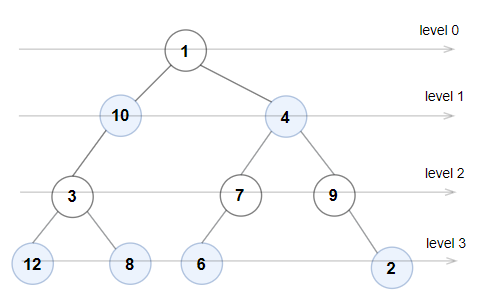

In [ ]:
from collections import deque

def evenOddTree(root):
    if root is None:
        return False
    
    queue = deque([(root, 0)])
    even = True
    while queue:
        prev = float('inf')
        if even:
            prev = float('-inf')
        for _ in range(len(queue)):
            node, curr_level = queue.popleft()
            
            # if level is even.
            if even and curr_level > 0:
                # return false if the value is even or not in decreasing order
                if node.value % 2 == 0 or (prev > node.value):
                    return False
            # if level is odd.
            elif not even and curr_level > 0:
                # return false if the value is odd or not in increasing order
                if node.value % 2 == 1 or (prev < node.value):
                    return False
            
            prev = node.value
            if node.left:
                queue.append((node.left, curr_level + 1))
            if node.right:
                queue.append((node.right, curr_level + 1))
            
        even = not even
    return True

evenOddTree(root)
        

True